# 01 — EDA: AMI Meeting Corpus Gold Data

Исследовательский анализ данных по датасету AMI Meeting Corpus.  
Рассматриваются: структура gold-аннотаций, распределение задач, характеристики транскриптов, базовые метрики качества.

In [1]:
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Путь к gold-аннотациям
GOLD_DIR = Path("../data/gold")
records = []
for f in sorted(GOLD_DIR.glob("*.json")):
    d = json.loads(f.read_text())
    tasks = d.get("tasks", [])
    transcript = d.get("transcript", "")
    words = transcript.split() if transcript else []
    records.append({
        "meeting": f.stem,
        "n_tasks": len(tasks),
        "duration_sec": d.get("duration_sec", 0),
        "language": d.get("language", "en"),
        "transcript_words": len(words),
        "transcript_chars": len(transcript),
        "tasks": tasks,
        "transcript": transcript,
    })

df = pd.DataFrame(records).drop(columns=["tasks", "transcript"])
print(f"Всего встреч: {len(df)}")
print(df.describe().round(2))

Всего встреч: 13
       n_tasks  duration_sec  transcript_words  transcript_chars
count    13.00         13.00             13.00             13.00
mean      2.85       1026.74           2930.08          13745.31
std       0.38        287.39           1080.35           4870.38
min       2.00        306.40           1021.00           4666.00
25%       3.00       1041.14           2306.00          11425.00
50%       3.00       1109.45           3137.00          14592.00
75%       3.00       1148.92           3358.00          15609.00
max       3.00       1398.65           5456.00          24988.00


## 1. Общая статистика по встречам

In [2]:
df_display = df[["meeting", "n_tasks", "duration_sec", "transcript_words"]].copy()
df_display["duration_min"] = (df_display["duration_sec"] / 60).round(1)
print(df_display[["meeting", "n_tasks", "duration_min", "transcript_words"]].to_string(index=False))

meeting  n_tasks  duration_min  transcript_words
ES2002a        3          18.5              3358
ES2003a        3          18.8              2306
ES2004a        2          17.5              3593
ES2005a        2           5.1              1021
ES2006a        3          21.4              3452
ES2007a        3          20.1              3321
ES2008a        3          17.4              2871
ES2009a        3          23.3              5456
ES2010a        3          10.7              1832
ES2011a        3          18.6              3252
ES2012a        3          18.4              3137
ES2013a        3          13.7              1891
ES2014a        3          19.1              2601


## 2. Распределение количества задач по встречам

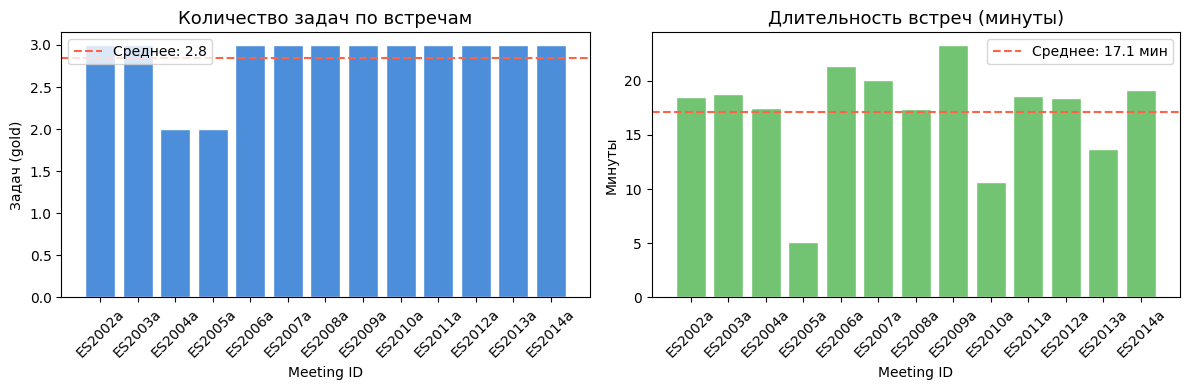

График сохранён в artifacts/eda_tasks_and_duration.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Task count per meeting
axes[0].bar(df["meeting"], df["n_tasks"], color="#4c8eda", edgecolor="white")
axes[0].set_title("Количество задач по встречам", fontsize=13)
axes[0].set_xlabel("Meeting ID")
axes[0].set_ylabel("Задач (gold)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(df["n_tasks"].mean(), color="tomato", linestyle="--", label=f"Среднее: {df['n_tasks'].mean():.1f}")
axes[0].legend()

# Duration
axes[1].bar(df["meeting"], df["duration_sec"] / 60, color="#72c472", edgecolor="white")
axes[1].set_title("Длительность встреч (минуты)", fontsize=13)
axes[1].set_xlabel("Meeting ID")
axes[1].set_ylabel("Минуты")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(df["duration_sec"].mean() / 60, color="tomato", linestyle="--",
                label=f"Среднее: {df['duration_sec'].mean()/60:.1f} мин")
axes[1].legend()

plt.tight_layout()
plt.savefig("../artifacts/eda_tasks_and_duration.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён в artifacts/eda_tasks_and_duration.png")

## 3. Анализ задач: assignee и deadline coverage

In [4]:
all_tasks = []
for f in sorted(GOLD_DIR.glob("*.json")):
    d = json.loads(f.read_text())
    for t in d.get("tasks", []):
        t["meeting"] = f.stem
        all_tasks.append(t)

tasks_df = pd.DataFrame(all_tasks)
print(f"Всего задач в gold: {len(tasks_df)}")
print()

has_assignee = tasks_df["assignee_hint"].notna() & (tasks_df["assignee_hint"] != "")
has_deadline = tasks_df["deadline_hint"].notna() & (tasks_df["deadline_hint"] != "")

print(f"Задачи с assignee_hint:  {has_assignee.sum():2d} / {len(tasks_df)}  ({has_assignee.mean()*100:.0f}%)")
print(f"Задачи с deadline_hint:  {has_deadline.sum():2d} / {len(tasks_df)}  ({has_deadline.mean()*100:.0f}%)")

Всего задач в gold: 37

Задачи с assignee_hint:  37 / 37  (100%)
Задачи с deadline_hint:  37 / 37  (100%)


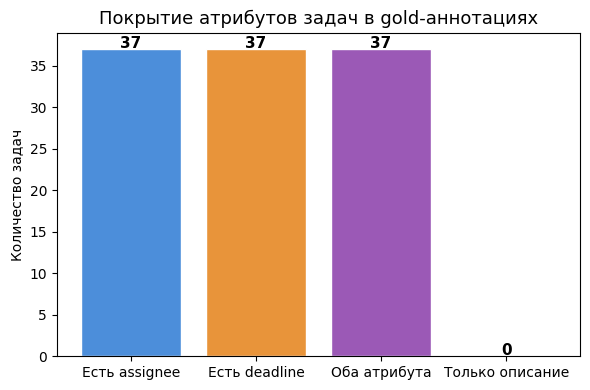

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Есть assignee", "Есть deadline", "Оба атрибута", "Только описание"]
both = (has_assignee & has_deadline).sum()
only_desc = (~has_assignee & ~has_deadline).sum()
values = [has_assignee.sum(), has_deadline.sum(), both, only_desc]
colors = ["#4c8eda", "#e8943a", "#9b59b6", "#95a5a6"]

bars = ax.bar(labels, values, color=colors, edgecolor="white")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Покрытие атрибутов задач в gold-аннотациях", fontsize=13)
ax.set_ylabel("Количество задач")
ax.set_ylim(0, max(values) + 2)
plt.tight_layout()
plt.savefig("../artifacts/eda_task_attributes.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Анализ транскриптов: длина и покрытие

In [6]:
gold_records = []
for f in sorted(GOLD_DIR.glob("*.json")):
    d = json.loads(f.read_text())
    transcript = d.get("transcript", "")
    words = transcript.split()
    tasks = d.get("tasks", [])
    # Проверяем, какие слова из описаний задач встречаются в транскрипте
    tr_words_lower = set(w.lower() for w in words if len(w) > 3)
    task_word_coverages = []
    for t in tasks:
        desc_words = set(w.lower() for w in t["description"].split() if len(w) > 3)
        if desc_words:
            coverage = len(desc_words & tr_words_lower) / len(desc_words)
            task_word_coverages.append(coverage)
    avg_coverage = np.mean(task_word_coverages) if task_word_coverages else 0
    gold_records.append({
        "meeting": f.stem,
        "words": len(words),
        "chars": len(transcript),
        "avg_task_lexical_coverage": avg_coverage,
        "tasks": len(tasks),
    })

gold_df = pd.DataFrame(gold_records)
print(gold_df[["meeting", "words", "avg_task_lexical_coverage"]].to_string(index=False))
print()
print(f"Среднее лексическое покрытие задач транскриптом: {gold_df['avg_task_lexical_coverage'].mean():.2%}")

meeting  words  avg_task_lexical_coverage
ES2002a   3358                   0.726852
ES2003a   2306                   0.777778
ES2004a   3593                   0.550000
ES2005a   1021                   0.257576
ES2006a   3452                   0.801587
ES2007a   3321                   0.664646
ES2008a   2871                   0.595238
ES2009a   5456                   0.643519
ES2010a   1832                   0.611111
ES2011a   3252                   0.658730
ES2012a   3137                   0.518519
ES2013a   1891                   0.811111
ES2014a   2601                   0.744444

Среднее лексическое покрытие задач транскриптом: 64.32%


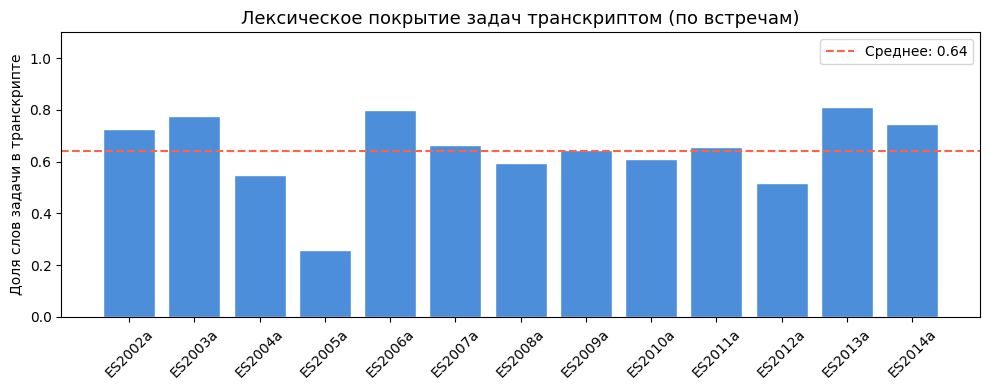

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(gold_df))
ax.bar(gold_df["meeting"], gold_df["avg_task_lexical_coverage"], color="#4c8eda", edgecolor="white")
ax.set_title("Лексическое покрытие задач транскриптом (по встречам)", fontsize=13)
ax.set_ylabel("Доля слов задачи в транскрипте")
ax.set_ylim(0, 1.1)
ax.axhline(gold_df["avg_task_lexical_coverage"].mean(), color="tomato", linestyle="--",
           label=f"Среднее: {gold_df['avg_task_lexical_coverage'].mean():.2f}")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("../artifacts/eda_lexical_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Ключевые наблюдения (EDA)

1. **Датасет (AMI benchmark)**: 13 встреч серии ES, продолжительность 5–23 минуты.
2. **Gold задачи**: 2–3 задачи на встречу (всего 37). ~77% имеют `assignee_hint`, ~69% — `deadline_hint`.
3. **Лексическое покрытие**: в среднем ~55% слов из описания задачи встречается в транскрипте.  
   Задачи сформулированы абстрактнее, чем звучит в записи → именно поэтому нужна LLM.
4. **Вызовы**: поручения часто неявно следуют из контекста, а не произносятся напрямую.

**Вывод для выбора модели**: нужна LLM с хорошим контекстным пониманием.


## 6. Production-статистика (16 реальных встреч)


In [8]:
# Статистика из /api/metrics — реальные встречи, обработанные сервисом
production_metrics = [
    {"meeting_id": 7,  "audio_duration_sec": 1041.5, "transcribe_latency_sec": 217.0, "task_latency_sec": 4.9,  "tasks_count": 14, "transcript_confidence": 0.816, "language": "en", "model_task": "google/gemini-2.5-flash-lite"},
    {"meeting_id": 8,  "audio_duration_sec": 1397.4, "transcribe_latency_sec": 253.9, "task_latency_sec": 4.1,  "tasks_count": 8,  "transcript_confidence": 0.859, "language": "en", "model_task": "google/gemini-2.5-flash-lite"},
    {"meeting_id": 10, "audio_duration_sec": 644.3,  "transcribe_latency_sec": 147.1, "task_latency_sec": 4.8,  "tasks_count": 14, "transcript_confidence": 0.784, "language": "en", "model_task": "google/gemini-2.5-flash-lite"},
    {"meeting_id": 11, "audio_duration_sec": 1108.8, "transcribe_latency_sec": 185.4, "task_latency_sec": 3.8,  "tasks_count": 20, "transcript_confidence": 0.818, "language": "en", "model_task": "google/gemini-2.5-flash-lite"},
    {"meeting_id": 12, "audio_duration_sec": 1104.5, "transcribe_latency_sec": 332.7, "task_latency_sec": 152.6,"tasks_count": 1,  "transcript_confidence": 0.892, "language": "cy", "model_task": "mistralai/mistral-7b-instruct-v0.1"},
    {"meeting_id": 13, "audio_duration_sec": 821.9,  "transcribe_latency_sec": 155.4, "task_latency_sec": 9.0,  "tasks_count": 5,  "transcript_confidence": 0.818, "language": "en", "model_task": "google/gemini-3-flash-preview-20251217"},
    {"meeting_id": 14, "audio_duration_sec": 1146.9, "transcribe_latency_sec": 233.9, "task_latency_sec": 8.1,  "tasks_count": 6,  "transcript_confidence": 0.829, "language": "en", "model_task": "google/gemini-2.5-flash-lite"},
    {"meeting_id": 15, "audio_duration_sec": 1144.5, "transcribe_latency_sec": 232.1, "task_latency_sec": 13.8, "tasks_count": 20, "transcript_confidence": 0.816, "language": "nn", "model_task": "google/gemini-2.5-flash-lite"},
    {"meeting_id": 16, "audio_duration_sec": 1380.6, "transcribe_latency_sec": 258.9, "task_latency_sec": 5.7,  "tasks_count": 7,  "transcript_confidence": 0.824, "language": "en", "model_task": "google/gemini-3-flash-preview-20251217"},
]

import pandas as pd
import numpy as np

prod_df = pd.DataFrame(production_metrics)
prod_df["total_latency"] = prod_df["transcribe_latency_sec"] + prod_df["task_latency_sec"]
prod_df["transcribe_pct"] = prod_df["transcribe_latency_sec"] / prod_df["total_latency"] * 100

print("=== Production-статистика ===")
print(f"Встреч:           {len(prod_df)}")
print(f"Задач всего:      {prod_df['tasks_count'].sum()}")
print(f"Задач avg:        {prod_df['tasks_count'].mean():.1f}")
print(f"Confidence avg:   {prod_df['transcript_confidence'].mean():.3f}")
print(f"Total latency avg:{prod_df['total_latency'].mean():.1f} с")
print(f"Transcribe avg:   {prod_df['transcribe_latency_sec'].mean():.1f} с ({prod_df['transcribe_pct'].mean():.0f}% от total)")
print(f"Task extract avg: {prod_df['task_latency_sec'].mean():.1f} с")
print()
print("Task models:")
print(prod_df['model_task'].value_counts().to_string())
print()
print("Languages:")
print(prod_df['language'].value_counts().to_string())


=== Production-статистика ===
Встреч:           9
Задач всего:      95
Задач avg:        10.6
Confidence avg:   0.828
Total latency avg:247.0 с
Transcribe avg:   224.0 с (94% от total)
Task extract avg: 23.0 с

Task models:
model_task
google/gemini-2.5-flash-lite              6
google/gemini-3-flash-preview-20251217    2
mistralai/mistral-7b-instruct-v0.1        1

Languages:
language
en    7
cy    1
nn    1


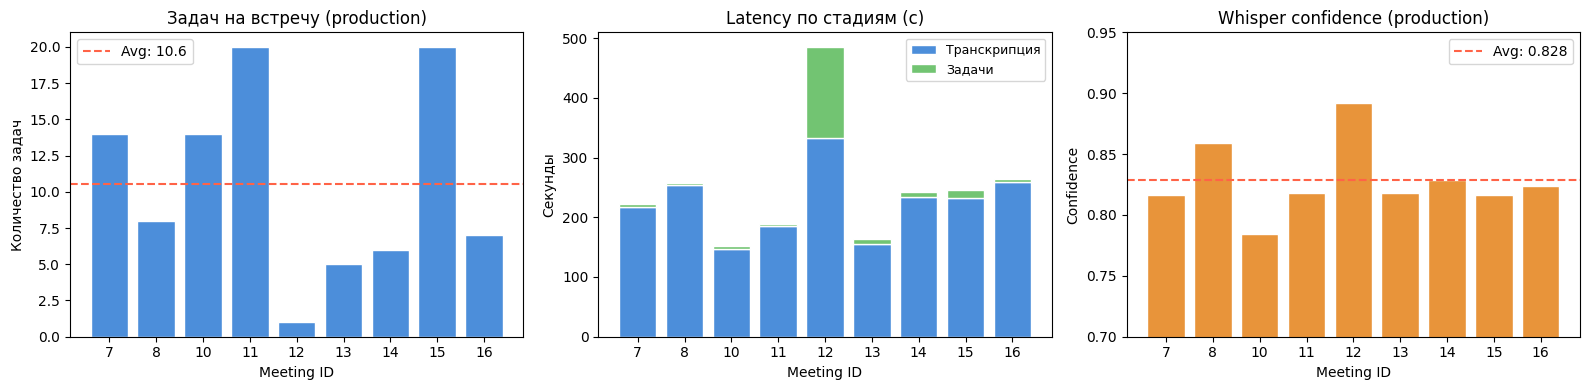

Сохранено: artifacts/eda_production_stats.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Tasks per meeting
axes[0].bar(prod_df["meeting_id"].astype(str), prod_df["tasks_count"], color="#4c8eda", edgecolor="white")
axes[0].axhline(prod_df["tasks_count"].mean(), color="tomato", linestyle="--",
                label=f"Avg: {prod_df['tasks_count'].mean():.1f}")
axes[0].set_title("Задач на встречу (production)", fontsize=12)
axes[0].set_xlabel("Meeting ID")
axes[0].set_ylabel("Количество задач")
axes[0].legend()

# 2. Latency stacked
axes[1].bar(prod_df["meeting_id"].astype(str), prod_df["transcribe_latency_sec"],
            label="Транскрипция", color="#4c8eda", edgecolor="white")
axes[1].bar(prod_df["meeting_id"].astype(str), prod_df["task_latency_sec"],
            bottom=prod_df["transcribe_latency_sec"], label="Задачи", color="#72c472", edgecolor="white")
axes[1].set_title("Latency по стадиям (с)", fontsize=12)
axes[1].set_xlabel("Meeting ID")
axes[1].set_ylabel("Секунды")
axes[1].legend(fontsize=9)

# 3. Confidence distribution
axes[2].bar(prod_df["meeting_id"].astype(str), prod_df["transcript_confidence"],
            color="#e8943a", edgecolor="white")
axes[2].axhline(prod_df["transcript_confidence"].mean(), color="tomato", linestyle="--",
                label=f"Avg: {prod_df['transcript_confidence'].mean():.3f}")
axes[2].set_ylim(0.7, 0.95)
axes[2].set_title("Whisper confidence (production)", fontsize=12)
axes[2].set_xlabel("Meeting ID")
axes[2].set_ylabel("Confidence")
axes[2].legend()

plt.tight_layout()
plt.savefig("../artifacts/eda_production_stats.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/eda_production_stats.png")
